# HMM-Informed LSTM

This notebook trains the next LSTM variant using the causal HMM regime features saved by `hmm_regime.ipynb`.

The target is still `Next_Day_Log_Return`. The regime inputs are `HMM_Bullish_Prob_Next` and `HMM_Bearish_Prob_Next`, computed as `filtered_probs @ hmm.transmat_`, so they align with the next-day prediction target without using future observations.


## 1. Imports and configuration


In [1]:
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from forecast_metrics import evaluate_directional_forecast

HMM_FEATURE_PATH = Path("outputs/hmm/hmm_regime_features.parquet")
METRICS_DIR = Path("outputs/metrics")
PREDICTIONS_DIR = Path("outputs/predictions")
MODEL_DIR = Path("models")

METRICS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LOOKBACK = 60
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 15
MODEL_NAME = "hmm_informed_lstm"


## 2. Load HMM regime features


In [2]:
if not HMM_FEATURE_PATH.exists():
    raise FileNotFoundError(
        "outputs/hmm/hmm_regime_features.parquet was not found. "
        "Run hmm_regime.ipynb first."
    )

model_df = pd.read_parquet(HMM_FEATURE_PATH)
model_df["Date"] = pd.to_datetime(model_df["Date"])
model_df["Target_Date"] = pd.to_datetime(model_df["Target_Date"])
model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
tickers = sorted(model_df["Ticker"].unique())

print("Loaded HMM feature dataframe:", model_df.shape)
print("Tickers:", tickers)
display(model_df.head())


Loaded HMM feature dataframe: (11889, 47)
Tickers: ['AAPL', 'IBM', 'MSFT']


,Date,Open,High,Low,Close,Volume,Ticker,Log_Close,Log_Return,Simple_Return,...,HMM_Prob_State_0_Next,HMM_Prob_State_1,HMM_Prob_State_1_Next,HMM_Bullish_Prob,HMM_Bearish_Prob,HMM_Bullish_Prob_Next,HMM_Bearish_Prob_Next,HMM_Bullish_State,HMM_Bearish_State,HMM_Features
0,2010-03-31,7.049493,7.083020,7.018659,7.034823,430659600,AAPL,1.950873,-0.003611,-0.003605,...,0.013974,1.000000,0.986026,1.000000,7.052034e-46,0.986026,0.013974,1,0,"Log_Return, Rolling_Vol_20"
1,2010-04-01,7.106970,7.146485,6.967471,7.063863,603145200,AAPL,1.954992,0.004120,0.004128,...,0.014790,0.999148,0.985210,0.999148,8.524932e-04,0.985210,0.014790,1,0,"Log_Return, Rolling_Vol_20"
2,2010-04-05,7.034229,7.139901,7.027942,7.139302,684507600,AAPL,1.965615,0.010623,0.010680,...,0.015053,0.998873,0.984947,0.998873,1.127500e-03,0.984947,0.015053,1,0,"Log_Return, Rolling_Vol_20"
3,2010-04-06,7.130617,7.191686,7.094695,7.170731,447017200,AAPL,1.970008,0.004393,0.004402,...,0.014891,0.999041,0.985109,0.999041,9.586893e-04,0.985109,0.014891,1,0,"Log_Return, Rolling_Vol_20"
4,2010-04-07,7.171031,7.241978,7.144388,7.202464,628502000,AAPL,1.974423,0.004416,0.004425,...,0.014976,0.998953,0.985024,0.998953,1.046836e-03,0.985024,0.014976,1,0,"Log_Return, Rolling_Vol_20"


## 3. Feature checks


In [3]:
target_col = "Next_Day_Log_Return"
base_feature_cols = [
    "Log_Return", "High_Low_Range", "Open_Close_Log_Return", "Volume_Change",
    "Rolling_Vol_5", "Rolling_Vol_10", "Rolling_Vol_20", "Rolling_Vol_60",
    "Momentum_5", "Momentum_10", "Momentum_20", "Momentum_60",
    "MA_Gap_5", "MA_Gap_10", "MA_Gap_20", "MA_Gap_60", "Drawdown_20",
]
hmm_lstm_feature_cols = ["HMM_Bullish_Prob_Next", "HMM_Bearish_Prob_Next"]

required_cols = [
    "Ticker", "Date", "Target_Date", "Split", target_col,
    "HMM_State", "HMM_Regime_Label", "HMM_Bullish_Prob", "HMM_Bearish_Prob",
] + base_feature_cols + hmm_lstm_feature_cols

missing_cols = [col for col in required_cols if col not in model_df.columns]
if missing_cols:
    raise ValueError(f"Missing required HMM-informed LSTM columns: {missing_cols}")

if model_df[hmm_lstm_feature_cols].isna().any().any():
    raise ValueError("HMM next-step probability features contain missing values.")

if not np.allclose(
    model_df["HMM_Bullish_Prob_Next"] + model_df["HMM_Bearish_Prob_Next"],
    1.0,
    atol=1e-6,
):
    raise ValueError("Next-step HMM probabilities do not sum to 1.")

feature_cols = base_feature_cols + hmm_lstm_feature_cols
model_df = model_df.dropna(subset=feature_cols + [target_col, "Target_Date"]).copy()

print("Model rows after feature checks:", model_df.shape)
print("Number of LSTM input features:", len(feature_cols))
display(model_df[["Ticker", "Date", "Target_Date", "Split", target_col] + hmm_lstm_feature_cols].head())


Model rows after feature checks: (11889, 47)
Number of LSTM input features: 19


,Ticker,Date,Target_Date,Split,Next_Day_Log_Return,HMM_Bullish_Prob_Next,HMM_Bearish_Prob_Next
0,AAPL,2010-03-31,2010-04-01,train,0.004120,0.986026,0.013974
1,AAPL,2010-04-01,2010-04-05,train,0.010623,0.985210,0.014790
2,AAPL,2010-04-05,2010-04-06,train,0.004393,0.984947,0.015053
3,AAPL,2010-04-06,2010-04-07,train,0.004416,0.985109,0.014891
4,AAPL,2010-04-07,2010-04-08,train,-0.002705,0.985024,0.014976


## 4. Create LSTM sequences


In [4]:
def make_lstm_sequences_by_target_split(
    df: pd.DataFrame,
    split: str,
    feature_columns: list[str],
    target_column: str,
    lookback: int = 60,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    X, y, meta = [], [], []
    df = df.sort_values(["Ticker", "Date"]).copy()

    for ticker, g in df.groupby("Ticker"):
        g = g.sort_values("Date").reset_index(drop=True)
        values = g[feature_columns].to_numpy(dtype=np.float32)
        targets = g[target_column].to_numpy(dtype=np.float32)
        splits = g["Split"].to_numpy()
        input_dates = g["Date"].to_numpy()
        target_dates = g["Target_Date"].to_numpy()
        regime_labels = g["HMM_Regime_Label"].to_numpy()

        for idx in range(lookback - 1, len(g)):
            if splits[idx] != split:
                continue
            X.append(values[idx - lookback + 1:idx + 1])
            y.append(targets[idx])
            meta.append((ticker, input_dates[idx], target_dates[idx], splits[idx], regime_labels[idx]))

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    meta = pd.DataFrame(
        meta,
        columns=["Ticker", "Input_End_Date", "Target_Date", "Split", "HMM_Regime_Label"],
    )
    return X, y, meta


## 5. Train one HMM-informed LSTM per ticker


In [6]:
try:
    from lstm_architecture import (
        LSTMConfig,
        build_lstm_model,
        evaluate_regression,
        get_training_callbacks,
        set_global_seed,
    )
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow/Keras is required for the HMM-informed LSTM training cells. "
        "Install a TensorFlow version compatible with this notebook kernel, restart the kernel, and rerun from the imports cell."
    ) from exc

set_global_seed(5)


def scale_single_ticker_features(single_stock_df, feature_cols, split_col="Split"):
    single_stock_df = single_stock_df.copy()
    train_mask = single_stock_df[split_col] == "train"
    if not train_mask.any():
        raise ValueError("No training rows available for ticker-specific feature scaling.")

    scaler = StandardScaler()
    scaled_feature_cols = [f"{col}_scaled" for col in feature_cols]
    scaler.fit(single_stock_df.loc[train_mask, feature_cols])
    single_stock_df[scaled_feature_cols] = scaler.transform(single_stock_df[feature_cols])
    return single_stock_df, scaled_feature_cols, scaler


def train_single_stock_hmm_lstm(model_df, ticker, feature_cols, target_col, lookback=60, epochs=100, batch_size=32, patience=15):
    single_stock_df = model_df.loc[model_df["Ticker"] == ticker].copy()
    if single_stock_df.empty:
        raise ValueError(f"No rows found for ticker {ticker}.")

    single_stock_df, scaled_feature_cols_s, feature_scaler_s = scale_single_ticker_features(single_stock_df, feature_cols)

    X_train_s, y_train_s, meta_train_s = make_lstm_sequences_by_target_split(single_stock_df, "train", scaled_feature_cols_s, target_col, lookback)
    X_val_s, y_val_s, meta_val_s = make_lstm_sequences_by_target_split(single_stock_df, "validation", scaled_feature_cols_s, target_col, lookback)
    X_test_s, y_test_s, meta_test_s = make_lstm_sequences_by_target_split(single_stock_df, "test", scaled_feature_cols_s, target_col, lookback)

    if min(len(y_train_s), len(y_val_s), len(y_test_s)) == 0:
        raise ValueError(f"{ticker}: one of the splits has zero sequences. train={len(y_train_s)}, val={len(y_val_s)}, test={len(y_test_s)}")

    y_scaler_s = StandardScaler()
    y_train_s_scaled = y_scaler_s.fit_transform(y_train_s.reshape(-1, 1)).ravel()
    y_val_s_scaled = y_scaler_s.transform(y_val_s.reshape(-1, 1)).ravel()

    config = LSTMConfig(lstm_units=(32,), dense_units=(16,), dropout=0.10, recurrent_dropout=0.0, learning_rate=1e-3, loss="mse", output_units=1)
    model_s = build_lstm_model(input_shape=(X_train_s.shape[1], X_train_s.shape[2]), config=config)

    history_s = model_s.fit(
        X_train_s,
        y_train_s_scaled,
        validation_data=(X_val_s, y_val_s_scaled),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_training_callbacks(model_path=MODEL_DIR / f"{MODEL_NAME}_{ticker}.keras", patience=patience),
        verbose=1,
        shuffle=True,
    )

    y_val_pred = y_scaler_s.inverse_transform(np.asarray(model_s.predict(X_val_s, verbose=0)).reshape(-1, 1)).ravel()
    y_pred_s = y_scaler_s.inverse_transform(np.asarray(model_s.predict(X_test_s, verbose=0)).reshape(-1, 1)).ravel()

    metrics_s = evaluate_regression(y_test_s, y_pred_s)
    diagnostics_s = {
        "ticker": ticker,
        "lookback": lookback,
        "n_features": len(feature_cols),
        "train_rows": int((single_stock_df["Split"] == "train").sum()),
        "val_rows": int((single_stock_df["Split"] == "validation").sum()),
        "test_rows": int((single_stock_df["Split"] == "test").sum()),
        "train_sequences": int(len(y_train_s)),
        "val_sequences": int(len(y_val_s)),
        "test_sequences": int(len(y_test_s)),
        "train_mean_return": float(y_train_s.mean()),
        "val_actual_std": float(y_val_s.std()),
        "test_actual_std": float(y_test_s.std()),
        "val_pred_std": float(y_val_pred.std()),
        "pred_std": float(y_pred_s.std()),
        "share_actual_positive": float(np.mean(y_test_s > 0)),
        "share_pred_positive": float(np.mean(y_pred_s > 0)),
    }

    def prediction_frame(meta_df, y_true, y_pred):
        pred_df = meta_df.rename(columns={"Ticker": "ticker", "Input_End_Date": "input_end_date", "Target_Date": "target_date", "Split": "split"}).copy()
        pred_df["y_true"] = y_true
        pred_df["y_pred"] = y_pred
        pred_df["model"] = MODEL_NAME
        pred_df["ticker"] = ticker
        return pred_df

    predictions = pd.concat(
        [prediction_frame(meta_val_s, y_val_s, y_val_pred), prediction_frame(meta_test_s, y_test_s, y_pred_s)],
        ignore_index=True,
    )

    print(f"Ticker: {ticker}")
    print(f"Validation sequences: {len(y_val_s)} | Test sequences: {len(y_test_s)}")
    print(f"Validation pred std: {diagnostics_s['val_pred_std']:.6f}")
    print(f"Test pred std      : {diagnostics_s['pred_std']:.6f}")

    return {
        "ticker": ticker,
        "model": model_s,
        "history": history_s,
        "feature_scaler": feature_scaler_s,
        "scaled_feature_cols": scaled_feature_cols_s,
        "y_scaler": y_scaler_s,
        "X_train": X_train_s,
        "X_val": X_val_s,
        "X_test": X_test_s,
        "y_train": y_train_s,
        "y_val": y_val_s,
        "y_test": y_test_s,
        "y_val_pred": y_val_pred,
        "y_pred": y_pred_s,
        "metrics": metrics_s,
        "diagnostics": diagnostics_s,
        "predictions": predictions,
        "metadata": {"train": meta_train_s, "validation": meta_val_s, "test": meta_test_s},
    }


In [7]:
hmm_informed_runs = {}
hmm_informed_rows = []

for ticker in tickers:
    run = train_single_stock_hmm_lstm(
        model_df=model_df,
        ticker=ticker,
        feature_cols=feature_cols,
        target_col=target_col,
        lookback=LOOKBACK,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patience=PATIENCE,
    )
    hmm_informed_runs[ticker] = run

    row = {"ticker": ticker, "model": MODEL_NAME}
    row.update(run["metrics"])
    row.update(run["diagnostics"])
    hmm_informed_rows.append(row)

hmm_informed_results_df = pd.DataFrame(hmm_informed_rows).sort_values("ticker").reset_index(drop=True)
hmm_informed_results_df


Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.0413 - mae: 0.7109 - val_loss: 1.1956 - val_mae: 0.8401 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.0138 - mae: 0.6997 - val_loss: 1.1927 - val_mae: 0.8414 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0074 - mae: 0.6969 - val_loss: 1.1911 - val_mae: 0.8395 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.9942 - mae: 0.6947 - val_loss: 1.1917 - val_mae: 0.8393 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9869 - mae: 0.6911 - val_loss: 1.1953 - val_mae: 0.8406 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.9860 - mae: 0.6932 - val_loss: 1.1941 - val_mae: 0.8410 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9819 - mae: 0.6912 - val_loss: 1.2013 - val_mae: 0.8448 - learning_rate: 0.0010
Epoch 

,ticker,model,mse,rmse,mae,r2,direction_accuracy,lookback,n_features,train_rows,...,train_sequences,val_sequences,test_sequences,train_mean_return,val_actual_std,test_actual_std,val_pred_std,pred_std,share_actual_positive,share_pred_positive
0,AAPL,hmm_informed_lstm,0.000255,0.015977,0.011060,0.011722,0.511968,60,19,2708,...,2649,503,752,0.001047,0.019405,0.016071,0.002386,0.001834,0.549202,0.647606
1,IBM,hmm_informed_lstm,0.000227,0.015052,0.010049,-0.018143,0.497340,60,19,2708,...,2649,503,752,0.000120,0.014803,0.014918,0.001613,0.001432,0.562500,0.562500
2,MSFT,hmm_informed_lstm,0.000217,0.014746,0.010620,-0.028149,0.519947,60,19,2708,...,2649,503,752,0.000916,0.018324,0.014542,0.003501,0.002711,0.542553,0.687500


## 6. Benchmark comparison and saved predictions


In [8]:
benchmark_rows = []
prediction_frames = []

for ticker in tickers:
    run = hmm_informed_runs[ticker]
    y_test_t = run["y_test"]
    y_train_t = run["y_train"]

    benchmark_rows.append({"ticker": ticker, "model": "zero_return", **evaluate_regression(y_test_t, np.zeros_like(y_test_t))})
    benchmark_rows.append({"ticker": ticker, "model": "train_mean_return", **evaluate_regression(y_test_t, np.full_like(y_test_t, y_train_t.mean(), dtype=np.float32))})
    benchmark_rows.append({"ticker": ticker, "model": MODEL_NAME, **run["metrics"]})
    prediction_frames.append(run["predictions"])

hmm_informed_benchmark_df = pd.DataFrame(benchmark_rows).sort_values(["ticker", "model"]).reset_index(drop=True)
hmm_informed_predictions_all_tickers = pd.concat(prediction_frames, ignore_index=True).sort_values(["ticker", "split", "target_date"]).reset_index(drop=True)

hmm_informed_results_df.to_csv(METRICS_DIR / "hmm_informed_lstm_metrics.csv", index=False)
hmm_informed_benchmark_df.to_csv(METRICS_DIR / "hmm_informed_lstm_benchmark_metrics.csv", index=False)

parquet_path = PREDICTIONS_DIR / "hmm_informed_lstm_predictions_all_tickers.parquet"
if importlib.util.find_spec("pyarrow") is None:
    raise RuntimeError("pyarrow is required for parquet export. Install it in the active kernel, restart the kernel, and rerun this cell.")

hmm_informed_predictions_all_tickers.to_parquet(parquet_path, index=False, engine="pyarrow")

print(hmm_informed_benchmark_df)
print(f"Saved metrics to {METRICS_DIR}")
print(f"Saved predictions to {parquet_path}")


  ticker              model       mse      rmse       mae        r2  \
0   AAPL  hmm_informed_lstm  0.000255  0.015977  0.011060  0.011722   
1   AAPL  train_mean_return  0.000258  0.016071  0.010947 -0.000008   
2   AAPL        zero_return  0.000259  0.016102  0.011011 -0.003885   
3    IBM  hmm_informed_lstm  0.000227  0.015052  0.010049 -0.018143   
4    IBM  train_mean_return  0.000224  0.014952  0.009961 -0.004619   
5    IBM        zero_return  0.000224  0.014961  0.009976 -0.005776   
6   MSFT  hmm_informed_lstm  0.000217  0.014746  0.010620 -0.028149   
7   MSFT  train_mean_return  0.000211  0.014542  0.010476 -0.000011   
8   MSFT        zero_return  0.000212  0.014574  0.010521 -0.004396   

   direction_accuracy  
0            0.511968  
1            0.549202  
2            0.002660  
3            0.497340  
4            0.562500  
5            0.001330  
6            0.519947  
7            0.542553  
8            0.000000  
Saved metrics to outputs\metrics
Saved prediction

## 7. Directional evaluation


In [9]:
directional_rows = []

for ticker in tickers:
    run = hmm_informed_runs[ticker]
    y_train_t = run["y_train"]
    y_test_t = run["y_test"]
    y_pred_t = run["y_pred"]

    lstm_dir = evaluate_directional_forecast(y_test_t, y_pred_t, threshold=0.0, verbose=False)
    lstm_dir["ticker"] = ticker
    lstm_dir["model"] = f"{MODEL_NAME}_threshold_0"
    directional_rows.append(lstm_dir)

    always_up = evaluate_directional_forecast(y_test_t, np.full_like(y_test_t, 1e-6), threshold=0.0, verbose=False)
    always_up["ticker"] = ticker
    always_up["model"] = "always_up"
    directional_rows.append(always_up)

    always_down = evaluate_directional_forecast(y_test_t, np.full_like(y_test_t, -1e-6), threshold=0.0, verbose=False)
    always_down["ticker"] = ticker
    always_down["model"] = "always_down"
    directional_rows.append(always_down)

    majority_pred = np.full_like(y_test_t, 1e-6 if np.mean(y_train_t > 0) >= 0.5 else -1e-6)
    majority_label = "majority_up" if np.mean(y_train_t > 0) >= 0.5 else "majority_down"
    majority = evaluate_directional_forecast(y_test_t, majority_pred, threshold=0.0, verbose=False)
    majority["ticker"] = ticker
    majority["model"] = majority_label
    directional_rows.append(majority)

hmm_informed_directional_df = pd.DataFrame(directional_rows).sort_values(["ticker", "model"]).reset_index(drop=True)
hmm_informed_directional_df.to_csv(METRICS_DIR / "hmm_informed_lstm_directional_metrics.csv", index=False)

hmm_informed_directional_df[
    ["ticker", "model", "direction_accuracy", "balanced_accuracy", "hm_stat", "share_predicted_up", "mean_directional_value", "mean_always_up_value"]
]


,ticker,model,direction_accuracy,balanced_accuracy,hm_stat,share_predicted_up,mean_directional_value,mean_always_up_value
0,AAPL,always_down,0.450798,0.500000,1.000000,0.000000,-0.001002,0.001002
1,AAPL,always_up,0.549202,0.500000,1.000000,1.000000,0.001002,0.001002
2,AAPL,hmm_informed_lstm_threshold_0,0.513298,0.498761,0.997522,0.647606,0.000868,0.001002
3,AAPL,majority_up,0.549202,0.500000,1.000000,1.000000,0.001002,0.001002
4,IBM,always_down,0.437500,0.500000,1.000000,0.000000,-0.001134,0.001134
5,IBM,always_up,0.562500,0.500000,1.000000,1.000000,0.001134,0.001134
6,IBM,hmm_informed_lstm_threshold_0,0.497340,0.489362,0.978723,0.562500,-0.000416,0.001134
7,IBM,majority_up,0.562500,0.500000,1.000000,1.000000,0.001134,0.001134
8,MSFT,always_down,0.457447,0.500000,1.000000,0.000000,-0.000964,0.000964
9,MSFT,always_up,0.542553,0.500000,1.000000,1.000000,0.000964,0.000964


## 8. Optional comparison to the baseline LSTM


In [10]:
baseline_metrics_path = METRICS_DIR / "single_stock_lstm_metrics.csv"

if baseline_metrics_path.exists():
    baseline_metrics = pd.read_csv(baseline_metrics_path).assign(model="baseline_lstm")
    comparison_df = pd.concat(
        [
            baseline_metrics[["ticker", "model", "rmse", "mae", "r2", "direction_accuracy"]],
            hmm_informed_results_df[["ticker", "model", "rmse", "mae", "r2", "direction_accuracy"]],
        ],
        ignore_index=True,
    ).sort_values(["ticker", "model"])
    display(comparison_df)
else:
    print("Baseline metrics file not found; run preprocessing_baseline_models.ipynb if you want a side-by-side comparison.")


,ticker,model,rmse,mae,r2,direction_accuracy
0,AAPL,baseline_lstm,0.016226,0.011123,-0.019385,0.515957
3,AAPL,hmm_informed_lstm,0.015977,0.011060,0.011722,0.511968
1,IBM,baseline_lstm,0.015056,0.010098,-0.018638,0.480053
4,IBM,hmm_informed_lstm,0.015052,0.010049,-0.018143,0.497340
2,MSFT,baseline_lstm,0.014844,0.010684,-0.041888,0.507979
5,MSFT,hmm_informed_lstm,0.014746,0.010620,-0.028149,0.519947


## 9. Prediction plots


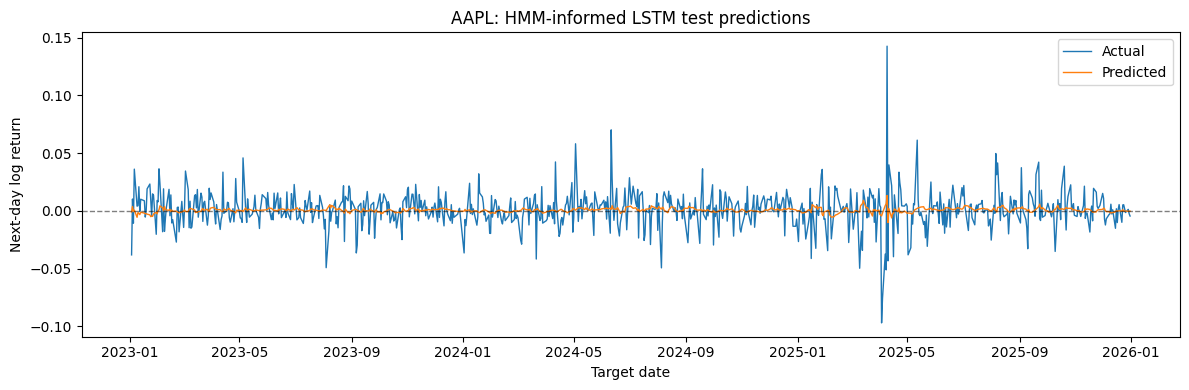

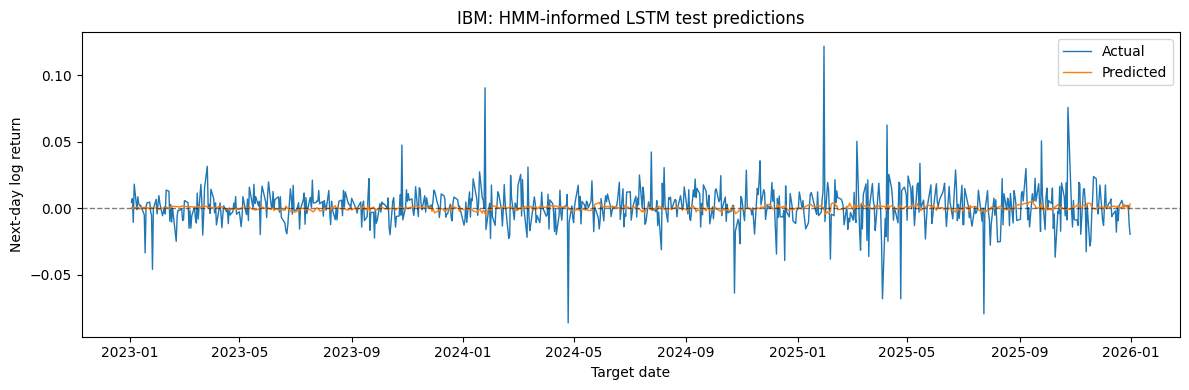

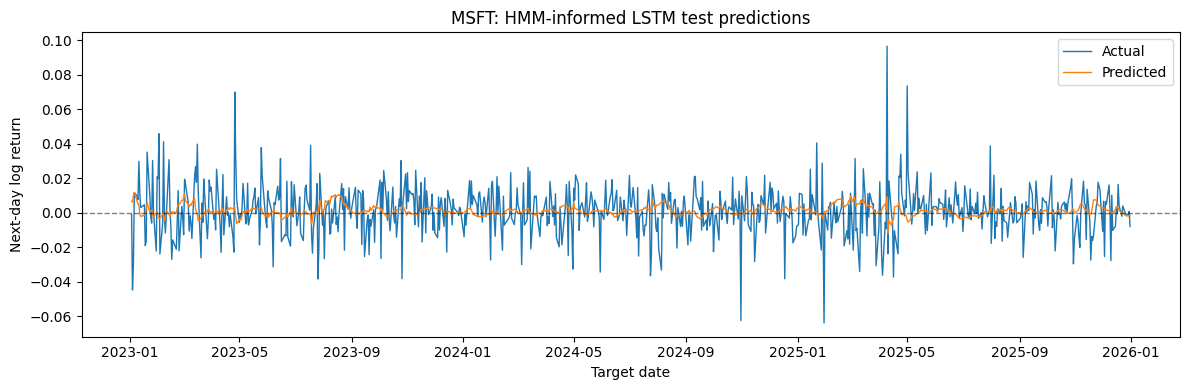

In [11]:
for ticker in tickers:
    pred_t = hmm_informed_predictions_all_tickers.loc[
        (hmm_informed_predictions_all_tickers["ticker"] == ticker)
        & (hmm_informed_predictions_all_tickers["split"] == "test")
    ].copy()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pred_t["target_date"], pred_t["y_true"], label="Actual", linewidth=1.0)
    ax.plot(pred_t["target_date"], pred_t["y_pred"], label="Predicted", linewidth=1.0)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(f"{ticker}: HMM-informed LSTM test predictions")
    ax.set_xlabel("Target date")
    ax.set_ylabel("Next-day log return")
    ax.legend()
    fig.tight_layout()
    plt.show()


## Interpretation

This notebook keeps the baseline LSTM setup but adds the HMM next-step regime probabilities as input features. The regime probabilities are fitted ticker by ticker, using only the HMM training split for the HMM parameters and scaler. The LSTM feature scaler and target scaler are also fitted ticker by ticker on training rows only.

The current filtered HMM probabilities are retained in the saved HMM file for diagnostics. The LSTM uses `HMM_Bullish_Prob_Next` and `HMM_Bearish_Prob_Next` because the supervised target is next-day return.
